# Data

> Data classes and functions

In [1]:
#| default_exp data

In [2]:
#| hide
from nbdev.showdoc import *

## Data types

### Meta resolver

In [68]:
#| export

class MetaResolver(type(torch.Tensor), metaclass=BypassNewMeta):
    """
    A class to bypass metaclass conflict:
    https://pytorch-geometric.readthedocs.io/en/latest/_modules/torch_geometric/data/batch.html
    """
    pass
    

### BioImageBase

In [69]:
#| export

from bioMONAI.core import show_images_grid
from bioMONAI.io import img_reader
from monai.data import MetaTensor


In [70]:

#| export
class BioImageBase(MetaTensor, metaclass=MetaResolver):
    """
    A class that represents an image object.
    Metaclass casts `x` to this class if it is of type `cls._bypass_type`.
    """
    
    _bypass_type = torch.Tensor  # The type that bypasses image loading
    _show_args = {'cmap': 'gray'}  # Default arguments for image display
    resample, reorder = None, False  # Default resample and reorder settings
    affine_matrix = None  # Default affine matrix for image transformation

    @classmethod
    def create(cls, fn: (Path, str, List, torch.Tensor), **kwargs) -> torch.Tensor: 
        """
        Opens an image and casts it to BioImageBase object.
        If `fn` is a torch.Tensor, it's cast to BioImageBase object.

        Args:
            fn : (Path, str, torch.Tensor)
                Image path or a 4D torch.Tensor.
            kwargs : dict
                Additional parameters for the medical image reader.

        Returns:
            torch.Tensor : A 4D tensor as a BioImageBase object.
        """
        if isinstance(fn, torch.Tensor):
            return cls(fn)

        return img_reader(fn, dtype=cls, resample=cls.resample, reorder=cls.reorder)

    @classmethod
    def item_preprocessing(cls, resample: (List, int, tuple), reorder: bool):
        """
        Changes the values for the class variables `resample` and `reorder`.

        Args:
            resample : (List, int, tuple)
                A list with voxel spacing.
            reorder : bool
                Whether to reorder the data to be closest to canonical (RAS+) orientation.
        """
        cls.resample = resample
        cls.reorder = reorder

    def show(self, ctx=None, figsize: int = None, ncols: int = 10, **kwargs):
        """
        Plots 2D slices of a 3D image alongside a prior specified axis.

        Args:
            ctx : Context to use for the display. Defaults to None.
            figsize: Size of the figure. Defaults to None.
            ncols: Number of columns in the grid. Defaults to 10.
            **kwargs : Additional keyword arguments passed to plt.imshow.

        Returns:
            Shown image.
        """
        return show_images_grid(self, ctx=ctx, ncols=ncols, **merge(self._show_args, kwargs))
    
    def as_tensor(self) -> torch.Tensor:
        """
        Return the `MetaTensor` as a `torch.Tensor`.
        It is OS dependent as to whether this will be a deep copy or not.
        """
        return self.as_subclass(torch.Tensor)

    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
        return f"BioImageBase{self.as_tensor().__repr__()[6:]}"

### BioImage 

class for 2D Images

In [71]:
#| export

class BioImage(BioImageBase):
    """Subclass of BioImageBase that represents 2D and 3D image objects."""
    _show_args = {'cmap':'gray'}
    
    @classmethod
    def create(cls, fn: (Path, str, L, list, torch.Tensor), **kwargs) -> torch.Tensor: 
        """
        Opens an image and casts it to BioImageBase object.
        If `fn` is a torch.Tensor, it's cast to BioImageBase object.

        Args:
            fn : (Path, str, torch.Tensor)
                Image path or a 4D torch.Tensor.
            kwargs : dict
                Additional parameters for the medical image reader.

        Returns:
            torch.Tensor : A 3D tensor as a BioImage object.
        """
        if isinstance(fn, torch.Tensor):
            return cls(fn)

        return torch.squeeze(img_reader(fn, dtype=cls, resample=cls.resample, reorder=cls.reorder), 1)
    
    def show(self, ctx=None, **kwargs):
        "Show image using `merge(self._show_args, kwargs)`"
        return show_image(self, ctx=ctx, **merge(self._show_args, kwargs))
    
    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
    #     return f'{self.__class__.__name__} shape={"x".join([str(d) for d in self.shape])}'
        return f"BioImage{self.as_tensor().__repr__()[6:]}"

In [72]:
a = BioImage.create('../../bioMONAI_0/_data/Babesia/RI/O11_RI_frame01.tiff')
print(a.shape)
a = BioImage.create('../../bioMONAI_0/_data/Babesia/TRITC/O11_TRITC_frame01.tiff')
print(a.shape)



a = BioImage.create('../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset_2/inputs/1.tif')
print(a.shape)
a = BioImage.create('../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset_2/targets/1.tif')
print(a.shape)





torch.Size([1, 96, 512, 512])
torch.Size([1, 512, 512])
torch.Size([1, 56, 2048, 2048])
torch.Size([1, 2048, 2048])


### BioImageStack

class for 3D images

In [73]:
#| export

class BioImageStack(BioImageBase):
    """Subclass of BioImageBase that represents a 3D image object."""
    
    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
        return f"BioImageStack{self.as_tensor().__repr__()[6:]}"

In [74]:
# a = BioImageStack.create('../../bioMONAI_0/_data/Babesia/RI/O11_RI_frame01.tiff')
# print(a.shape)
# a = BioImageStack.create('../../bioMONAI_0/_data/Babesia/TRITC/O11_TRITC_frame01.tiff')
# a.shape

### BioImageProject

2D representations of 3D stack using maximum intensity projection

In [75]:
#| export

class BioImageProject(BioImageBase):
    """Subclass of BioImageBase that represents a 2D image object."""
    _show_args = {'cmap':'gray'}
    
    @classmethod
    def create(cls, fn: (Path, str, L, list, torch.Tensor), **kwargs) -> torch.Tensor: 
        """
        Opens an image and casts it to BioImageBase object.
        If `fn` is a torch.Tensor, it's cast to BioImageBase object.

        Args:
            fn : (Path, str, torch.Tensor)
                Image path or a 4D torch.Tensor.
            kwargs : dict
                Additional parameters for the medical image reader.

        Returns:
            torch.Tensor : A 3D tensor as a BioImage object.
        """
        if isinstance(fn, torch.Tensor):
            return cls(fn)

        img = img_reader(fn, dtype=cls, resample=cls.resample, reorder=cls.reorder)
        return torch.max(img, dim=1)[0]  # Taking the maximum intensity projection along axis 1
    
    def show(self, ctx=None, **kwargs):
        "Show image using `merge(self._show_args, kwargs)`"
        return show_image(self, ctx=ctx, **merge(self._show_args, kwargs))
    
    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
        return f"BioImage{self.as_tensor().__repr__()[6:]}"

In [76]:
a = BioImageProject.create('../../bioMONAI_0/_data/Babesia/RI/O11_RI_frame01.tiff')
#a = BioImageProject.create('../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset_2/inputs/1.tif')
a.shape

torch.Size([1, 512, 512])

### BioImageMulti

Multichannel datasets

In [77]:
#| export

class BioImageMulti(BioImageBase):
    """Subclass of BioImageBase that represents a multi-channel 2D image object."""
    
    @classmethod
    def create(cls, fn: (Path, str, L, list, torch.Tensor), **kwargs) -> torch.Tensor: 
        """
        Opens an image and casts it to BioImageBase object.
        If `fn` is a torch.Tensor, it's cast to BioImageBase object.

        Args:
            fn : (Path, str, torch.Tensor)
                Image path or a 4D torch.Tensor.
            kwargs : dict
                Additional parameters for the medical image reader.

        Returns:
            torch.Tensor : A 3D tensor as a BioImage object.
        """
        if isinstance(fn, torch.Tensor):
            return cls(fn)

        return torch.squeeze(img_reader(fn, dtype=cls, resample=cls.resample, reorder=cls.reorder), 0)
    
    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
        return f"BioImageMulti{self.as_tensor().__repr__()[6:]}"
        

In [78]:
# a = BioImageMulti.create('../../bioMONAI_0/_data/Babesia/RI/O11_RI_frame01.tiff')#'../_data/Babesia/RI/O11_RI_frame01.tiff'
# print(a.shape)

### BioImage4D

4D datasets

In [79]:
# TO DO

class BioImage4D(BioImageBase):
    """Subclass of BioImageBase that represents a (multi-channel) 3D image object."""
    
    @classmethod
    def create(cls, fn: (Path, str, L, list, torch.Tensor), **kwargs) -> torch.Tensor: 
        """
        Opens an image and casts it to BioImageBase object.
        If `fn` is a torch.Tensor, it's cast to BioImageBase object.

        Args:
            fn : (Path, str, torch.Tensor)
                Image path or a 4D torch.Tensor.
            kwargs : dict
                Additional parameters for the medical image reader.

        Returns:
            torch.Tensor : A 3D tensor as a BioImage object.
        """
        if isinstance(fn, torch.Tensor):
            return cls(fn)

        return torch.squeeze(img_reader(fn, dtype=cls, resample=cls.resample, reorder=cls.reorder), 1)
    
    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
        return f"BioImage4D{self.as_tensor().__repr__()[6:]}"

In [80]:
# a = BioImage4D.create('../../bioMONAI_0/_data/Babesia/RI/O11_RI_frame01.tiff')#'../_data/Babesia/RI/O11_RI_frame01.tiff'
# print(a.shape)


tensor = torch.randn(3,10, 4, 5)
b = BioImage4D.create(tensor)#'../_data/Babesia/RI/O11_RI_frame01.tiff'
print(b.shape)

torch.Size([3, 10, 4, 5])


### Data conversion

In [81]:
#| export

class Tensor2BioImage(DisplayedTransform):
    def __init__(self, cls:BioImageBase=BioImageStack):
        self.cls = cls

    def encodes(self, o):
        if isinstance(o, MetaTensor):
            return self.cls(o.clone(), affine=o.affine, meta=o.meta)
        
        if isinstance(o, torch.Tensor):
            return self.cls(o)

## Data blocks

### ImageBlock

In [82]:
#| export

def BioImageBlock(cls:BioImageBase=BioImageStack):
    "A `TransformBlock` for images of `cls`"
    return TransformBlock(type_tfms=cls.create, batch_tfms=[Tensor2BioImage(cls)]) # IntToFloatTensor

## Display

### Show batch

In [83]:
#| export 

@typedispatch
def show_batch(x:BioImageBase, y:BioImageBase, samples, ctxs=None, max_n=10, nrows=None, ncols=None, figsize=None, **kwargs):
    if ctxs is None: ctxs = get_grid(min(len(samples), max_n), nrows=nrows, ncols=ncols, figsize=figsize, double=True)
    for i in range(2):
        ctxs[i::2] = [b.show(ctx=c, **kwargs) for b,c,_ in zip(samples.itemgot(i),ctxs[i::2],range(max_n))]
    return ctxs

### Show results

In [84]:
#| export 

@typedispatch
def show_results(x:BioImageBase, y:BioImageBase, samples, outs, ctxs=None, max_n=10, figsize=None, **kwargs):
    if ctxs is None: ctxs = get_grid(3*min(len(samples), max_n), ncols=3, figsize=figsize, title='Input/Target/Prediction')
    for i in range(2):
        ctxs[i::3] = [b.show(ctx=c, **kwargs) for b,c,_ in zip(samples.itemgot(i),ctxs[i::3],range(max_n))]
    ctxs[2::3] = [b.show(ctx=c, **kwargs) for b,c,_ in zip(outs.itemgot(0),ctxs[2::3],range(max_n))]
    return ctxs

## Example

In [85]:
from monai.transforms import ScaleIntensity
from bioMONAI.transforms import *

In [86]:
spatial_dimensions = 2
roi_size = [32]*spatial_dimensions
item_tfms = [RandCropND(roi_size), ScaleIntensity] 

In [87]:
from bioMONAI.core import get_target

Setting affine, but the applied meta contains an affine. This will be overwritten.
Setting affine, but the applied meta contains an affine. This will be overwritten.


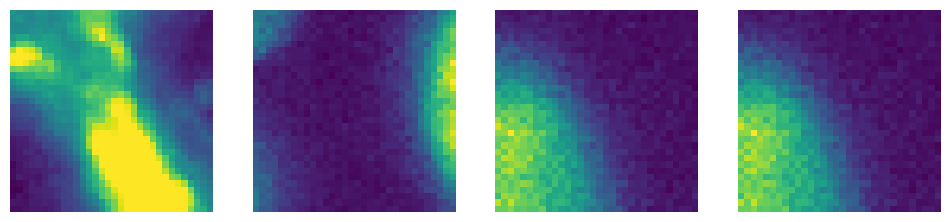

In [101]:
file_folder = '../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset_2'

dblock = DataBlock(blocks=(BioImageBlock(cls=BioImageProject), BioImageBlock(cls=BioImageProject)),
                   get_items=get_image_files,
                   get_y=get_target('../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset_2/targets', same_filename=True),
                   splitter=RandomSplitter(valid_pct=0.2),
                   item_tfms=item_tfms,
                   )
# dblock.summary(file_folder)

dls = dblock.dataloaders(file_folder, bs=2)
dls.show_batch(max_n=2, cmap='viridis')

In [102]:
from monai.networks.nets import DynUNet
from monai.losses import SSIMLoss

In [103]:
model = DynUNet(spatial_dims=spatial_dimensions, in_channels=1, out_channels=1, strides=(1, 2, 2),kernel_size=(3, 3, 3), upsample_kernel_size=(2, 2), res_block=True)

In [104]:
loss_func = SSIMLoss(spatial_dims=spatial_dimensions)

In [105]:
learn = Learner(dls, model, loss_func=loss_func)

In [106]:
learn.summary()

Setting affine, but the applied meta contains an affine. This will be overwritten.


DynUNet (Input shape: 2 x 1 x 32 x 32)
Layer (type)         Output Shape         Param #    Trainable 
                     2 x 32 x 32 x 32    
Conv2d                                    288        True      
Conv2d                                    9216       True      
LeakyReLU                                                      
InstanceNorm2d                            64         True      
InstanceNorm2d                            64         True      
Conv2d                                    32         True      
InstanceNorm2d                            64         True      
____________________________________________________________________________
                     2 x 64 x 16 x 16    
Conv2d                                    18432      True      
Conv2d                                    36864      True      
LeakyReLU                                                      
InstanceNorm2d                            128        True      
InstanceNorm2d                  

In [107]:
learn.fit_flat_cos(5,1e-3)

epoch,train_loss,valid_loss,time
0,0.999406,0.999052,00:10
1,0.995351,0.998416,00:10
2,0.971927,0.943298,00:09
3,0.860400,0.580867,00:10
4,0.698286,0.279059,00:09


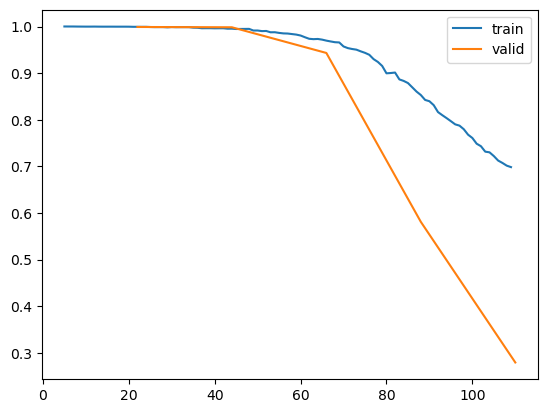

In [108]:
learn.recorder.plot_loss()

Setting affine, but the applied meta contains an affine. This will be overwritten.


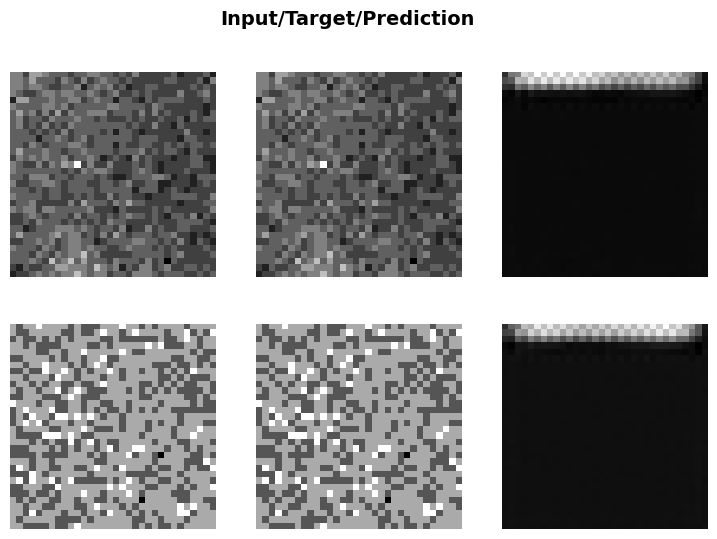

In [109]:
learn.show_results(cmap='gray')

In [112]:
#| hide
import nbdev; nbdev.nbdev_export()